In [13]:
import pickle
import os

from matplotlib import pyplot as plt
import numpy as np
import scipy as sp


import morph_analyses as m

%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Morph-binned trial x trial similarity matrix

In [14]:
def single_sess_simmat(sess):

    # load data
    S = sess.timeseries['spks_norm']
    S[np.isnan(S)]=0
    
    trial_info, S_trial_mat = sess.trial_info, sess.trial_matrices['spks_norm']
    S_trial_mat[np.isnan(S_trial_mat)]=0
    
    
    S_tmat_norm = np.copy(S_trial_mat).reshape(S_trial_mat.shape[0],-1)
    S_tmat_norm = S_tmat_norm/np.linalg.norm(S_tmat_norm,ord=2,axis=-1,keepdims=True)
    C = np.matmul(S_tmat_norm,S_tmat_norm.T)
    C[np.diag_indices_from(C)]=np.nan

    C_binned = np.zeros((5,5))
    for i,_m in enumerate([0,.25,.5,.75,1.]):
        for j,mm in enumerate([0,.25,.5,.75,1.]):
            __C = C[trial_info['morphs']==_m,:]
            __C = __C[:,trial_info['morphs']==mm]
            C_binned[i,j] = np.nanmean(__C)
    
    # similarity fraction
    rtsf = m.utilities.rt_similarity_fraction(S_trial_mat,trial_info)

    rtsf_binned = np.zeros((5,rtsf.shape[1]))
    for i,_m in enumerate([0,.25,.5,.75,1.]):
        rtsf_binned[i,:] = rtsf[trial_info['morphs']==_m,:].mean(axis=0)
    
    
    return C_binned, rtsf_binned

In [62]:
def run_sessions(sessions):
    C_mat = []
    rtsf_mat = []
    for mouse, metadata in sessions.items():
        print(mouse)
        # d['mouse'] = {}
        C_binned, rtsf_binned = 0, 0
        for i, sess_deets in enumerate(metadata['test_sessions']):
            sess = m.sess.CA1MorphSession.from_nwb(mouse, 'testing', sess_deets['day'])
            _C_binned, _rtsf_binned = single_sess_simmat(sess)
            C_binned += _C_binned
            rtsf_binned += _rtsf_binned
        C_mat.append(C_binned[np.newaxis,:,:]/(i+1.))
        rtsf_mat.append(rtsf_binned[np.newaxis, :, :]/(i+1.))
            
    return np.concatenate(C_mat,axis=0), np.concatenate(rtsf_mat, axis=0)

In [63]:
rare_C_mat, rare_rtsf_mat = run_sessions(m.mouse_metadata.rare_sessions)

R1
R2
R3
R4
R5
R6


Text(0, 0.5, 'S')

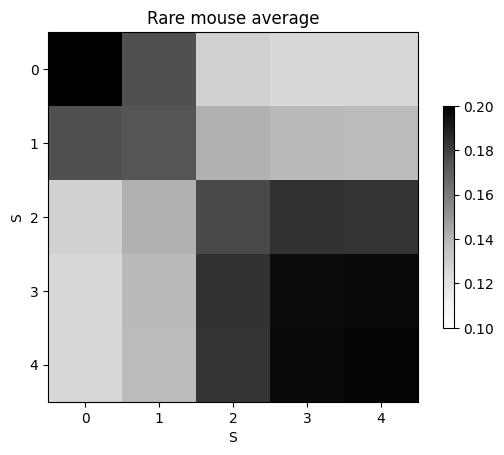

In [80]:
fig, ax = plt.subplots()
im = ax.imshow(rare_C_mat.mean(axis=0),cmap='Greys', vmin=.1, vmax=.2)
fig.colorbar(im, shrink=.6)
ax.set_title('Rare mouse average')
ax.set_xlabel('S')
ax.set_ylabel('S')

In [66]:
freq_C_mat, freq_rtsf_mat = run_sessions(m.mouse_metadata.frequent_sessions)

F1
F2
F3
F4
F5
F6


Text(0, 0.5, 'S')

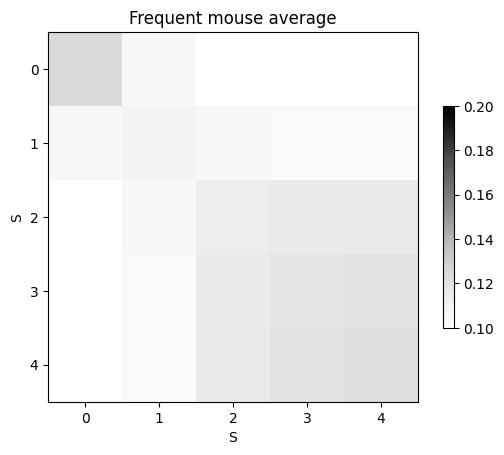

In [81]:
fig, ax = plt.subplots()
im = ax.imshow(freq_C_mat.mean(axis=0),cmap='Greys', vmin=.1, vmax=.2)
fig.colorbar(im, shrink=.6)
ax.set_title('Frequent mouse average')
ax.set_xlabel('S')
ax.set_ylabel('S')

Text(0, 0.5, 'S')

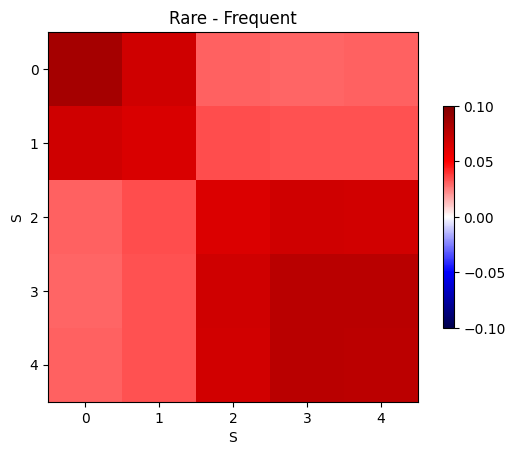

In [76]:
fig, ax = plt.subplots()
im = ax.imshow(rare_C_mat.mean(axis=0) - freq_C_mat.mean(axis=0), cmap='seismic', vmin=-.1, vmax=.1)
fig.colorbar(im, shrink=.6)
ax.set_title('Rare - Frequent')
ax.set_xlabel('S')
ax.set_ylabel('S')

Text(0, 0.5, 'S')

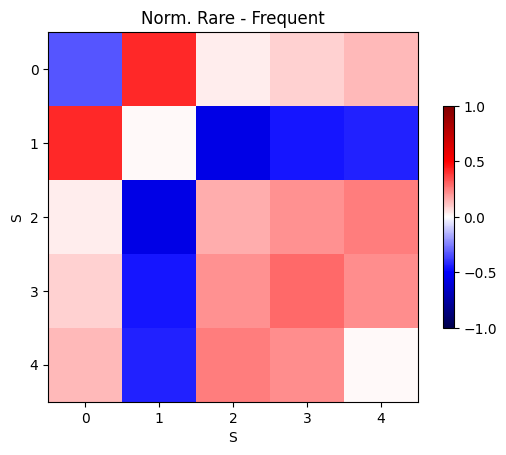

In [69]:
rare_C_mat_rs = rare_C_mat.reshape([rare_C_mat.shape[0],-1])
freq_C_mat_rs = freq_C_mat.reshape([freq_C_mat.shape[0],-1])

rare_C_mat_rs = sp.stats.zscore(rare_C_mat_rs, axis=-1)
freq_C_mat_rs = sp.stats.zscore(freq_C_mat_rs, axis=-1)

rare_C_mat_norm = rare_C_mat_rs.reshape(rare_C_mat.shape)
freq_C_mat_norm = freq_C_mat_rs.reshape(freq_C_mat.shape)


fig, ax = plt.subplots()
im = ax.imshow(rare_C_mat_norm.mean(axis=0) - freq_C_mat_norm.mean(axis=0), cmap='seismic', vmin=-1., vmax=1.)
fig.colorbar(im, shrink=.6)

ax.set_title('Norm. Rare - Frequent')
ax.set_xlabel('S')
ax.set_ylabel('S')

Text(0.5, 1.0, 'Frequent mice')

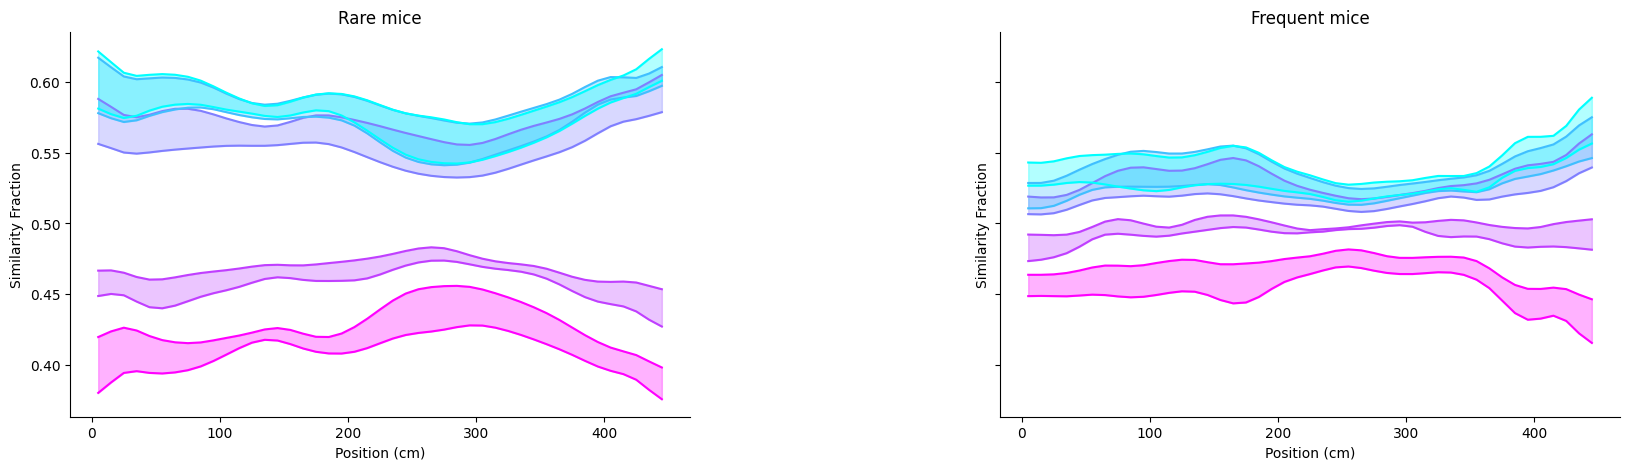

In [79]:
fig, ax = plt.subplots(1,2, figsize = [20,5], sharey=True)
fig.subplots_adjust(wspace=.5)

for _m, morph in enumerate([0,.25,.5,.75,1.]):
    mu, sem = rare_rtsf_mat[:,_m,:].mean(axis=0), sp.stats.sem(rare_rtsf_mat[:,_m,:], axis=0)
    ax[0].fill_between(np.arange(5,450,10),mu-sem,mu+sem,color=plt.cm.cool(float(1-morph)),alpha=.3)
    ax[0].plot(np.arange(5,450,10),mu-sem,color=plt.cm.cool(float(1-morph)))
    ax[0].plot(np.arange(5,450,10),mu+sem,color=plt.cm.cool(float(1-morph)))
    
    mu, sem = freq_rtsf_mat[:,_m,:].mean(axis=0), sp.stats.sem(freq_rtsf_mat[:,_m,:], axis=0)
    ax[1].fill_between(np.arange(5,450,10),mu-sem,mu+sem,color=plt.cm.cool(float(1-morph)),alpha=.3)
    ax[1].plot(np.arange(5,450,10),mu-sem,color=plt.cm.cool(float(1-morph)))
    ax[1].plot(np.arange(5,450,10),mu+sem,color=plt.cm.cool(float(1-morph)))
    
for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

    a.set_xlabel('Position (cm)')
    a.set_ylabel('Similarity Fraction')

ax[0].set_title('Rare mice')
ax[1].set_title('Frequent mice')